# Nitrate Analysis Walkthrough

The analysis applied to velocity datasets used in the project, originating from the dataset downloaded with initial QA/QC applied as in the [OOI Profiler Nitrate Retriever](https://github.com/andrew-s28/ooi-profiler-nitrate-retriever).

In [1]:
import warnings
from pathlib import Path

import cmocean.cm as cmo
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import xarray as xr

warnings.filterwarnings("ignore", category=RuntimeWarning, message="Mean of empty slice")

## Loading and initial visualization

In [2]:
NOTEBOOK_DIR = Path().resolve()
DATA_DIR = NOTEBOOK_DIR / "../data"
FIGURES_DIR = NOTEBOOK_DIR / "../figures"
INNER_NITRATE_PATH = DATA_DIR / "CE01ISSP/CE01ISSP_nitrate_binned_baseline_subtracted_2014-04-17_2023-09-17.nc"
MID_NITRATE_PATH = DATA_DIR / "CE02SHSP/CE02SHSP_nitrate_binned_baseline_subtracted_2015-03-18_2024-07-14.nc"

In [3]:
# start by loading and examining the nitrate dataset
inner_nitrate = xr.open_dataset(INNER_NITRATE_PATH)
mid_nitrate = xr.open_dataset(MID_NITRATE_PATH)
# examine nitrate
inner_nitrate

<xarray.Dataset> Size: 6MB
Dimensions:                                    (time: 2815, depth: 26)
Coordinates:
  * depth                                      (depth) float64 208B 1.0 ... 26.0
  * time                                       (time) datetime64[ns] 23kB 201...
Data variables:
    temperature                                (time, depth) float64 586kB ...
    salinity_corrected_nitrate_qartod_results  (time, depth) float32 293kB ...
    deployment                                 (time, depth) float64 586kB ...
    pressure                                   (time, depth) float64 586kB ...
    salinity_corrected_nitrate                 (time, depth) float64 586kB ...
    practical_salinity                         (time, depth) float64 586kB ...
    absolute_salinity                          (time, depth) float64 586kB ...
    conservative_temperature                   (time, depth) float64 586kB ...
    sigma_t                                    (time, depth) float64 586kB ...
    sigma_theta                                (time, depth) float64 586kB ...
Attributes: (12/68)
    node:                               SP001
    comment:                            
    publisher_email:                    
    sourceUrl:                          http://oceanobservatories.org/
    collection_method:                  recovered_cspp
    stream:                             nutnr_j_cspp_instrument_recovered
    ...                                 ...
    geospatial_lon_max:                 -124.09595
    geospatial_lon_units:               degrees_east
    geospatial_lon_resolution:          0.1
    geospatial_vertical_units:          meters
    geospatial_vertical_resolution:     0.1
    geospatial_vertical_positive:       down

Here we can see that the output of the retreival script is already binned and has some helpful thermodynamic quantities calculated (e.g., $\sigma_\theta$). However, the times are still per-profile - eventually we will take daily averages, but for now we will continue to work with the per-profile level data.

In [ ]:
def plot_nitrate(
    nitrate: xr.DataArray,
    vmin: float = -3,
    vmax: float = 40,
) -> None:
    """Plot the velocity profiles for each deployment period.

    Args:
        nitrate (xr.DataArray): A dataarray containing nitrate,
            with 'time' and 'depth' dimensions.
        vmin (float): Minimum value to plot in the colorbar.
        vmax (float): Maximum value to plot in the colorbar.

    """
    _, ax = plt.subplots(figsize=(12, 6))

    cmap = cmo.matter
    cmap.set_bad("gray", 1.0)

    pcm = ax.pcolormesh(
        nitrate["time"],
        -nitrate["depth"],
        nitrate.T,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )
    plt.colorbar(pcm, ax=ax, label="Nitrate Concentration ($\\mathsf{mmol \\; m^{-3}}$)", extend="both")

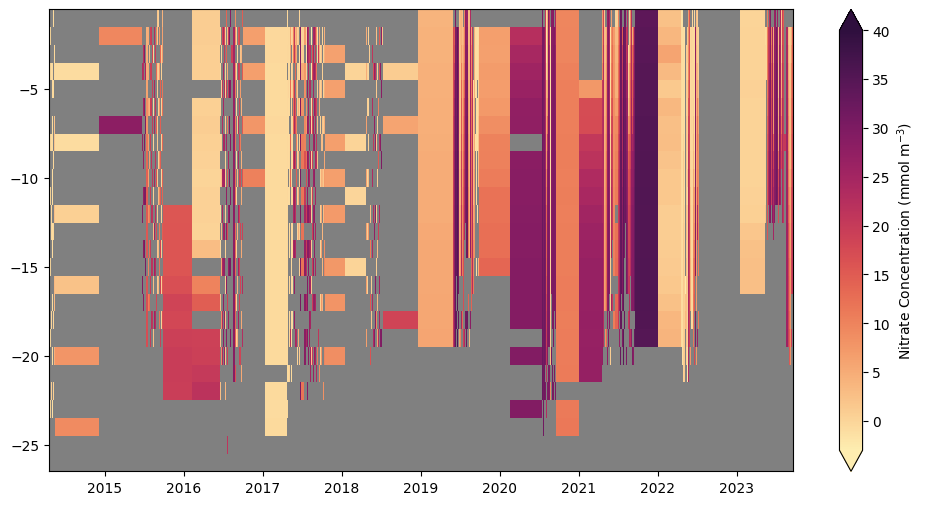

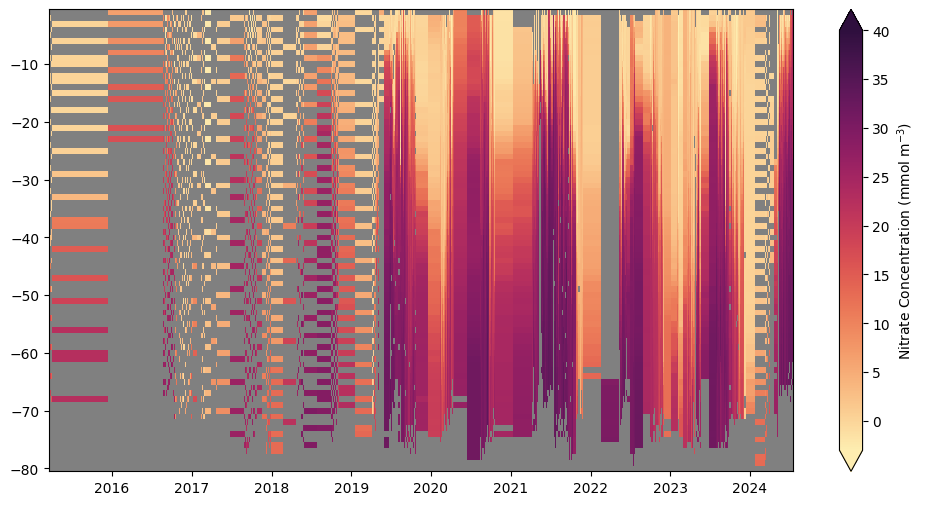

In [5]:
plot_nitrate(inner_nitrate["salinity_corrected_nitrate"])
plot_nitrate(mid_nitrate["salinity_corrected_nitrate"])

Okay, looking a bit rough! We will clean this up.

## Extrapolating to surface and bottom and filling gaps

We will first apply a linear interpolation over the time and depth dimensions, filling any gaps within and between proflies, up to a limit of 5 m in depth at the inner shelf and 10 m in depth at the mid shelf and 2 days in time at either (reasonable estimates of length/time scales of variability in nitrate).

First, we have to resample to daily means to ensure that we aren't interpolating over very different times (xarray doesn't take into account variable spacing in time when interpolating NaN).

In [6]:
# resample to daily mean, which fills NaNs into gaps in data
inner_nitrate_interp = inner_nitrate.resample(time="1D").mean()
mid_nitrate_interp = mid_nitrate.resample(time="1D").mean()

# interpolate gaps in the middle of profiles
inner_nitrate_interp = inner_nitrate_interp.interpolate_na(
    dim="time",
    method="polynomial",
    order=1,
    limit=2,
).interpolate_na(
    dim="depth",
    method="polynomial",
    order=1,
    limit=5,
)
mid_nitrate_interp = mid_nitrate_interp.interpolate_na(
    dim="time",
    method="polynomial",
    order=1,
    limit=2,
).interpolate_na(dim="depth", method="polynomial", order=1, limit=10)

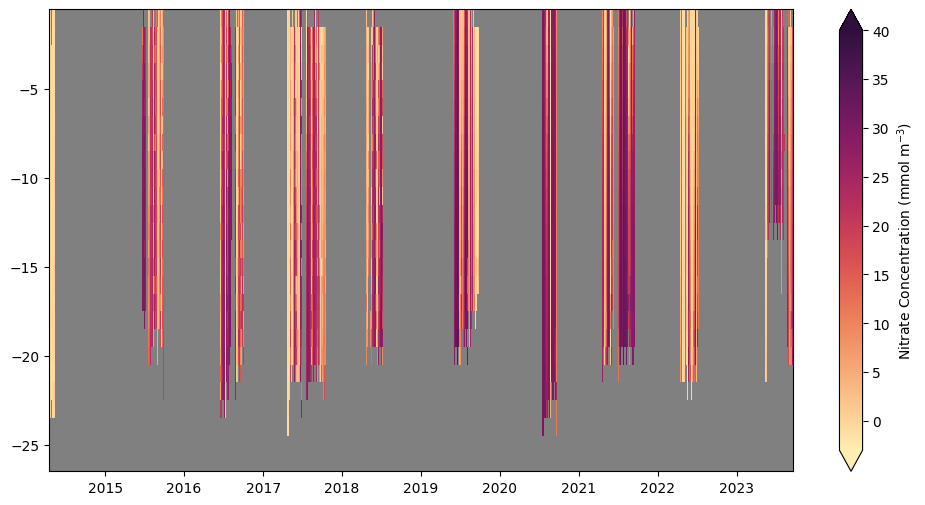

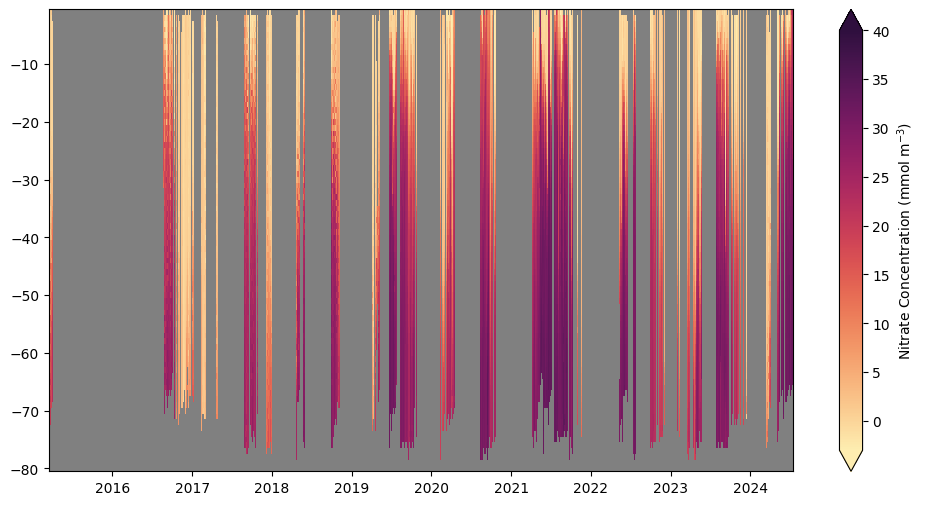

In [7]:
plot_nitrate(inner_nitrate_interp["salinity_corrected_nitrate"])
plot_nitrate(mid_nitrate_interp["salinity_corrected_nitrate"])

Great - better already. This is now a reflection of the data we actually have (matplotlib does some weird stuff with inconsistent time data when calculating pcolor plots).

Now we can go ahead with applying a constant extrapolation to the surface and bottom, again only applied over a depth of 5 m for the inner shelf and 10 m for the mid shelf.

In [8]:
def extrapolate_bottom_nitrate(
    nitrate: xr.Dataset,
    limit: int = 10,
) -> xr.Dataset:
    """Extrapolate bottom nitrate using constant nitrate extrapolation from the bottom-most depth.

    Args:
        nitrate (xr.Dataset): dataset containing nitrate data
        limit (int): maximum number of depth bins to extrapolate, default is 10 indices

    Returns:
        xr.Dataset: dataset with bottom nitrate linearly extrapolated to zero

    """
    # bfill will backfill the surface values with the nearest valid value, only within 20 m (2 m depth bins)
    nitrate = nitrate.ffill(dim="depth", limit=limit)

    return nitrate


def extrapolate_top_nitrate(
    nitrate: xr.Dataset,
    limit: int = 10,
) -> xr.Dataset:
    """Extrapolate top nitrate using constant nitrate extrapolation from the top-most depth.

    Args:
        nitrate (xr.Dataset): dataset containing nitrate data
        limit (int): maximum number of depth bins to extrapolate, default is 10 indices

    Returns:
        xr.Dataset (nitrate) - dataset with top nitrate extrapolated to constant value from the top-most depth

    """
    # bfill will backfill the surface values with the nearest valid value, only within 20 m (2 m depth bins)
    nitrate = nitrate.bfill(dim="depth", limit=limit)

    return nitrate

In [9]:
inner_nitrate_extrap = extrapolate_top_nitrate(inner_nitrate_interp, limit=10)
inner_nitrate_extrap = extrapolate_bottom_nitrate(inner_nitrate_extrap, limit=10)

mid_nitrate_extrap = extrapolate_top_nitrate(mid_nitrate_interp, limit=20)
mid_nitrate_extrap = extrapolate_bottom_nitrate(mid_nitrate_extrap, limit=20)

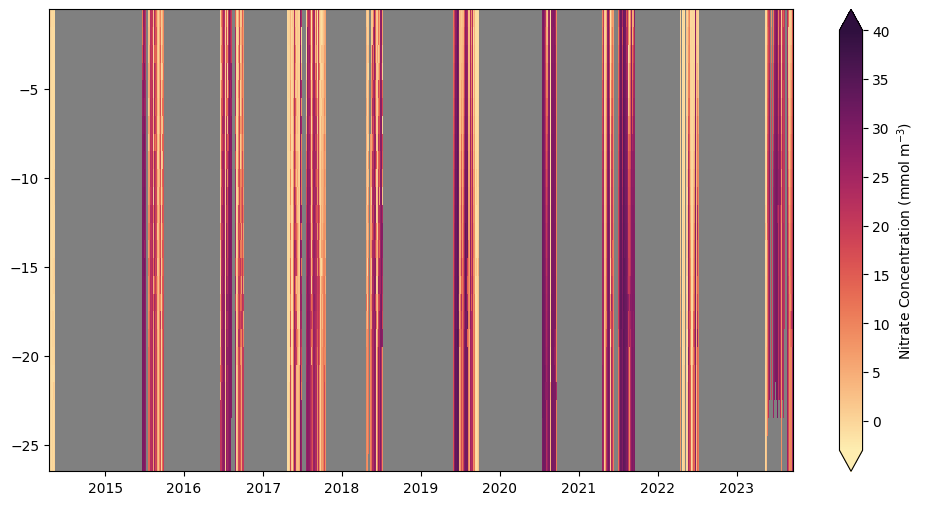

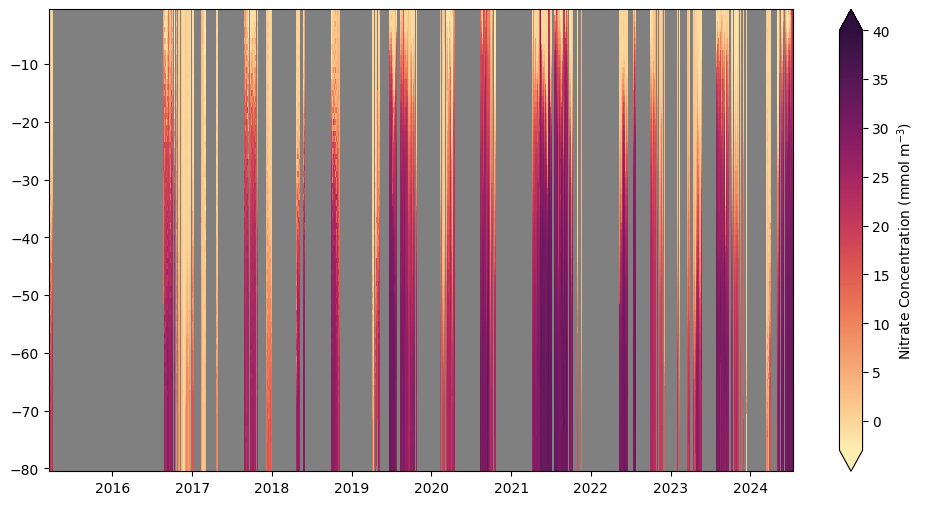

In [10]:
plot_nitrate(
    inner_nitrate_extrap["salinity_corrected_nitrate"],
)
plot_nitrate(
    mid_nitrate_extrap["salinity_corrected_nitrate"],
)

Now those are looking like some complete profiles!

## Calculating nitrate tendency

The next step is to calcluate the nitrate tendency (rate of change $\partial N / \partial t$). We will want to either calculate the depth-varying tendency which will then be integrated based on the cross-shelf bathymetry, or we can calculate the depth mean tendency which can then simply be multiplied by the control volume area (if we assume that the depth mean at one location is a good approximation of the depth mean throughout the control volume).

In [11]:
# depth varying dn/dt
inner_nitrate_extrap["dndt"] = inner_nitrate_extrap["salinity_corrected_nitrate"].differentiate(
    "time",
    datetime_unit="s",
)
mid_nitrate_extrap["dndt"] = mid_nitrate_extrap["salinity_corrected_nitrate"].differentiate(
    "time",
    datetime_unit="s",
)

# depth mean dn/dt
inner_nitrate_extrap["dndt_depth_mean"] = inner_nitrate_extrap["dndt"].mean(dim="depth")
mid_nitrate_extrap["dndt_depth_mean"] = mid_nitrate_extrap["dndt"].mean(dim="depth")

## Calculating nitrate budget

The first step of calculating the nitrate budget is to identify the bathmetry associated with the mid and inner shelf control volumes.

In [12]:
NHL_LAT = 44.66
GEBCO_PATH = list(Path(DATA_DIR / "GEBCO/").glob("*.nc"))

# load bathymetry and interpolate to the NHL latitude set above
bathymetry = (
    xr.open_mfdataset(GEBCO_PATH)
    .interp(lat=NHL_LAT)
    .interp(
        {"lon": np.linspace(-130, -120, int(1e6))},  # interpolate to a very high resolution covering the shelf
    )
)

# identify the coast by finding the longitude where the elevation is closest to zero
coast = bathymetry.isel({"lon": np.nanargmin(np.abs(bathymetry.elevation.values))})

# distance along line of constant latitude is given by dlon * R * cos(lat), with R=6371 km (radius of Earth)
bathymetry["distance_from_shore"] = (
    xr.ufuncs.deg2rad(bathymetry["lon"] - coast["lon"]) * 6371 * xr.ufuncs.cos(xr.ufuncs.deg2rad(NHL_LAT))
)

# use distance from shore as the new x coordinate instead of longitude
bathymetry = bathymetry.swap_dims({"lon": "distance_from_shore"})

Text(0, 0.5, 'z (m)')

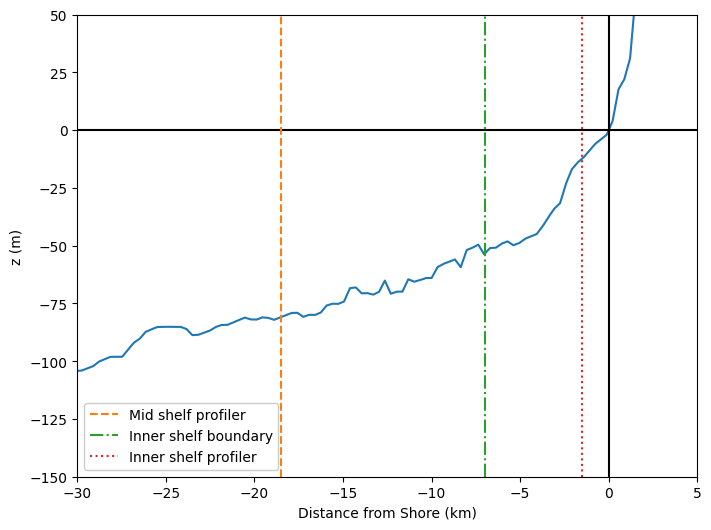

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(bathymetry["distance_from_shore"], bathymetry["elevation"])

ax.axhline(0, color="k", linestyle="-")
ax.axvline(0, color="k", linestyle="-")
ax.axvline(-18.5, color="C1", linestyle="--", label="Mid shelf profiler")
ax.axvline(-7, color="C2", linestyle="-.", label="Inner shelf boundary")
ax.axvline(-1.5, color="C3", linestyle=":", label="Inner shelf profiler")
ax.legend(loc="lower left", framealpha=1)

ax.set_xlim(-30, 5)
ax.set_ylim(-150, 50)

ax.set_xlabel("Distance from Shore (km)")
ax.set_ylabel("z (m)")

Now, there's at least two ways (probably more also) that we can reasonably calculate the nitrate tendency in each of these control volumes (the inner shelf represented by the inner shelf profiler, etc.).


The first method is to multiply the depth mean nitrate tendency by the total control volume area, which assumes that the depth mean nitrate tendency is representative of the volume mean nitrate tendency. This likely overestimates the nitrate concentration in each control volume, since it also implicitly assumes the near bottom nitrate concentration is relevant across the control volume (i.e., the isonitrate lines are "fully upwelled").


In [14]:
def calculate_tendency_based_on_scaling_profiles(
    dndt: xr.DataArray,
    elevation: xr.DataArray,
    d_min: float,
    d_max: float,
) -> xr.DataArray:
    """Calculate the volume of water in a 1 m wide control volume extending cross-shelf from d_min to d_max.

    Args:
        dndt (xr.DataArray): a dataarray containing the nitrate tendency, with 'time' and 'depth' dimensions
        elevation (xr.DataArray): a dataarray containing the elevation along the line of constant latitude,
            with 'distance_from_shore' coordinate
        d_min (float): the distance from shore defining the outer boundary of the control volume
        d_max (float): the distance from shore defining the inner boundary of the control volume

    Returns:
        xr.DataArray: a dataarray containing the tendency of nitrate in the specified control volume

    """
    # interpolate to 10 m resolution between d_min and d_max
    elevation = xr.ufuncs.abs(elevation.interp(distance_from_shore=np.arange(d_min, d_max, 0.01)))

    # volume = 1 m * 0.01 km (cross-shelf step size) * 1000 m/km (convert to meters) * depth (elevation in dataarray)
    volume = (0.01 * 1000 * elevation).sum()

    tendency = dndt.mean(dim="depth") * volume

    return tendency

In [15]:
inner_nitrate_extrap["tendency_based_on_scaling"] = calculate_tendency_based_on_scaling_profiles(
    inner_nitrate_extrap["dndt"],
    bathymetry["elevation"],
    -7,
    0,
)

mid_nitrate_extrap["tendency_based_on_scaling"] = calculate_tendency_based_on_scaling_profiles(
    mid_nitrate_extrap["dndt"],
    bathymetry["elevation"],
    -18.5,
    -7,
)

The second way is a little trickier, and involves depth integrating the depth-varying nitrate tendency only for depths that are greater than the depth of the bathymetry at each cross-shelf location. This is likely an underestimate of the total nitrate concentration, since it implicitly assumes the "relaxed" state of flat isonitrate lines.

In [16]:
def calculate_tendency_based_on_valid_depths(
    dndt: xr.DataArray,
    elevation: xr.DataArray,
    d_min: float,
    d_max: float,
) -> xr.DataArray:
    """Calculate the depth-integrated cross-shelf nitrate inventory in a control volume defined by d_min and d_max.

    Args:
        dndt (xr.DataArray): a dataarray containing the nitrate tendency, with 'time' and 'depth' dimensions
        elevation (xr.DataArray): a dataarray containing the elevation along the line of constant latitude,
            with 'distance_from_shore' coordinate
        d_min (float): the distance from shore defining the outer boundary of the control volume
        d_max (float): the distance from shore defining the inner boundary of the control volume

    Returns:
        xr.DataArray: a dataarray containing the depth-integrated cross-shelf nitrate inventory in the control volume

    """
    # interpolate to 10 m resolution between d_min and d_max
    elevation = xr.ufuncs.abs(elevation.interp(distance_from_shore=np.arange(d_min, d_max, 0.01)))

    # expand the depth into the cross-shelf dimension
    cross_shelf_depth, _ = xr.broadcast(dndt["depth"], elevation)

    # mask out depths that are deeper than the bathymetry at each cross-shelf point
    mask = cross_shelf_depth < xr.ufuncs.abs(elevation)

    # expand the dndt into the cross-shelf dimension
    cross_shelf_dndt, _ = xr.broadcast(dndt, elevation)

    # apply mask to set dndt to NaN at depths that are deeper than the bathymetry
    cross_shelf_dndt = cross_shelf_dndt.where(mask)

    # compute tendency by summing up depth mean nitrate times depth at each cross-shelf location
    # then sum in cross-shelf and multiply by cross-shelf step size and m per km conversion
    tendency = (
        (cross_shelf_dndt.mean(dim="depth") * xr.ufuncs.abs(elevation)).sum(dim="distance_from_shore") * 0.01 * 1000
    )

    return tendency

In [17]:
inner_nitrate_extrap["tendency_based_on_depth"] = calculate_tendency_based_on_valid_depths(
    inner_nitrate_extrap["dndt"],
    bathymetry["elevation"],
    -7,
    0,
)

mid_nitrate_extrap["tendency_based_on_depth"] = calculate_tendency_based_on_valid_depths(
    mid_nitrate_extrap["dndt"],
    bathymetry["elevation"],
    -18.5,
    -7,
)

Now that we havh versions calculated, let's compare the results through a linear regression analysis.

In [23]:
mask = np.isfinite(inner_nitrate_extrap["tendency_based_on_scaling"].values) & np.isfinite(
    inner_nitrate_extrap["tendency_based_on_depth"].values,
)

inner_ols = sm.OLS(
    inner_nitrate_extrap["tendency_based_on_depth"].values[mask],
    sm.add_constant(inner_nitrate_extrap["tendency_based_on_scaling"].values[mask]),
)
inner_results = inner_ols.fit()
inner_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 8.093e+05
Date:                Thu, 12 Mar 2026   Prob (F-statistic):               0.00
Time:                        19:58:44   Log-Likelihood:                -79.756
No. Observations:                 930   AIC:                             163.5
Df Residuals:                     928   BIC:                             173.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0018      0.009      0.214      0.831      -0.015       0.019
x1             1.0010      0.001    899.628      0.000       0.999       1.003
==============================================================================
Omnibus:                       52.082   Durbin-Watson:                   1.221
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              132.760
Skew:                           0.278   Prob(JB):                     1.48e-29
Kurtosis:                       4.766   Cond. No.                         7.78
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [24]:
mask = np.isfinite(mid_nitrate_extrap["tendency_based_on_scaling"].values) & np.isfinite(
    mid_nitrate_extrap["tendency_based_on_depth"].values,
)

mid_ols = sm.OLS(
    mid_nitrate_extrap["tendency_based_on_depth"].values[mask],
    sm.add_constant(mid_nitrate_extrap["tendency_based_on_scaling"].values[mask]),
)
mid_results = mid_ols.fit()
mid_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.988
Model:                            OLS   Adj. R-squared:                  0.988
Method:                 Least Squares   F-statistic:                 7.951e+04
Date:                Thu, 12 Mar 2026   Prob (F-statistic):               0.00
Time:                        19:59:01   Log-Likelihood:                -1469.5
No. Observations:                 997   AIC:                             2943.
Df Residuals:                     995   BIC:                             2953.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0093      0.034     -0.277      0.782      -0.075       0.056
x1             1.1188      0.004    281.981      0.000       1.111       1.127
==============================================================================
Omnibus:                      283.715   Durbin-Watson:                   1.396
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3455.742
Skew:                          -0.942   Prob(JB):                         0.00
Kurtosis:                      11.924   Cond. No.                         8.45
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Text(0, 0.5, 'Tendency based on depth (mmol/m/s)')

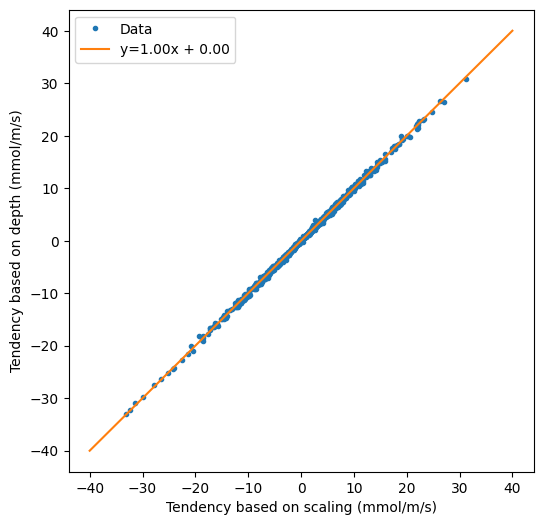

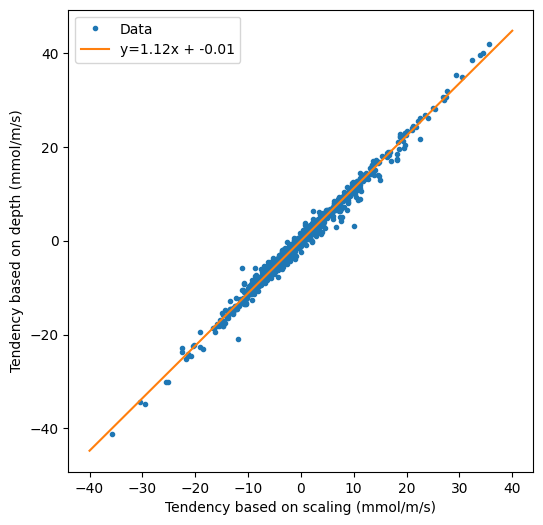

In [25]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(
    inner_nitrate_extrap["tendency_based_on_scaling"],
    inner_nitrate_extrap["tendency_based_on_depth"],
    ".",
    label="Data",
)
ax.plot(
    np.linspace(-40, 40, 100),
    np.linspace(-40, 40, 100) * inner_results.params[1] + inner_results.params[0],
    label=f"y={inner_results.params[1]:.2f}x + {inner_results.params[0]:.2f}",
)

ax.legend()

ax.set_xlabel("Tendency based on scaling (mmol/m/s)")
ax.set_ylabel("Tendency based on depth (mmol/m/s)")

fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(
    mid_nitrate_extrap["tendency_based_on_scaling"],
    mid_nitrate_extrap["tendency_based_on_depth"],
    ".",
    label="Data",
)
ax.plot(
    np.linspace(-40, 40, 100),
    np.linspace(-40, 40, 100) * mid_results.params[1] + mid_results.params[0],
    label=f"y={mid_results.params[1]:.2f}x + {mid_results.params[0]:.2f}",
)

ax.legend()

ax.set_xlabel("Tendency based on scaling (mmol/m/s)")
ax.set_ylabel("Tendency based on depth (mmol/m/s)")

Okay, so they're basically the same.

Interestingly, the tendency based on depth (which we expected to underestimate the depth mean nitrate concentration) actually is larger than the tendency based on scaling (which we expected to overestimate the depth mean nitrate concentration). The key here is that this is the rate of change of nitrate, which suggests that dN/dt tends to be *slightly* larger in the near surface than in the near bottom, at least at the midshelf.

At the inner shelf, there's absolutely no difference, which makes sense since there's much less depth-variability at the inner shelf than the mid-shelf.

In any case, and since none of the results change with this choice, we're just going to move forward using the tendency based on scaling since it's marginally easier to calculate.